# Impact of AI on Students

##### Data source https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/code

### <span style="color:purple">**Section 1: Dataset Introduction & Initial Exploration**</span>

##### The AI Impact on Students dataset is a Kaggle dataset created by Lavesh Jadon to examine how the use of AI tools relates to students' learning and academic performance. It contains 50,000 student records with 16 columns.

##### This dataset is interesting because it explores a timely issue: whether AI tools help, hinder, or change the way students learn. It allows researchers and students to analyze patterns between AI use and academic success, making it useful for exploratory analysis, machine learning projects, and educational research. The data is generated and is not a real data. I have chosen as it is an interesting topic.

#### Tasks:
1. Describe the dataset: what it contains, where it comes from, and why it is interesting
2. Load the data with pandas and display the first rows
3. Check shape, data types, and column names
4. Answer: How many rows? How many columns? What does each column represent?
5. Check for duplicates and summarise with .describe()

#### 1.1 Import Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('ai_student_impact_dataset (1).csv')
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [4]:
df.groupby("Major_Category")["Weekly_GenAI_Hours"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
).sort_values(by="mean", ascending=False)

,count,mean,median,std
Major_Category,,,,
STEM,15059,10.488609,7.40,9.733261
Business,12538,8.275898,5.82,8.011074
Medical,6476,7.546728,5.24,7.410775
Arts,5933,7.271702,5.07,7.042327
Humanities,9994,6.770144,4.72,6.586853


#### 1.2 Calculating columns, rows, duplicated rows and columns name

##### How many rows are there? How many columns are there?

In [6]:
df.shape

(50000, 16)

In [7]:
len(df)

50000

##### Is there any duplicate value?

In [8]:
df.duplicated().sum()

np.int64(0)

##### Columns names

In [9]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [10]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


### <span style="color:purple">**Section 2: Data Cleaning & Preparation**</span>

#### Tasks:
1. Identify and handle missing values (document your decisions)
2. Convert columns to the correct data types (especially dates)
3. Handle outliers: detect them, decide whether to remove or keep, and justify
4. Clean any text columns if needed (strip spaces, standardise categories)
5. Create at least one new feature through feature engineering

#### Missing values

In [11]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

##### What is the data types?

In [12]:
df.dtypes

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object

##### Outlier

In [13]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    """
    Detect outliers using the IQR method.
    
    Parameters:
    - data: DataFrame
    - column: Column name to check
    - multiplier: IQR multiplier (1.5 = standard, 3 = extreme outliers only)
    
    Returns:
    - DataFrame with outlier information
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print(f"=== IQR Analysis for '{column}' ===")
    print(f"Q1 (25th percentile): {Q1:.2f}")
    print(f"Q3 (75th percentile): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"\nOutliers found: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
    
    return outliers, lower_bound, upper_bound

# Apply to ai student impact dataset
numeric_cols = df.dtypes[(df.dtypes != "object")&(df.dtypes != "bool")].index

for column in numeric_cols:
    outliers, lb, ub = detect_outliers_iqr(df, column)
    print("\n-----------------------------------------------\n") 


=== IQR Analysis for 'Student_ID' ===
Q1 (25th percentile): 112500.75
Q3 (75th percentile): 137500.25
IQR: 24999.50
Lower bound: 75001.50
Upper bound: 174999.50

Outliers found: 0 (0.0%)

-----------------------------------------------

=== IQR Analysis for 'Pre_Semester_GPA' ===
Q1 (25th percentile): 2.83
Q3 (75th percentile): 3.52
IQR: 0.69
Lower bound: 1.80
Upper bound: 4.55

Outliers found: 328 (0.7%)

-----------------------------------------------

=== IQR Analysis for 'Weekly_GenAI_Hours' ===
Q1 (25th percentile): 2.39
Q3 (75th percentile): 11.72
IQR: 9.33
Lower bound: -11.61
Upper bound: 25.72

Outliers found: 2583 (5.2%)

-----------------------------------------------

=== IQR Analysis for 'Tool_Diversity' ===
Q1 (25th percentile): 2.00
Q3 (75th percentile): 4.00
IQR: 2.00
Lower bound: -1.00
Upper bound: 7.00

Outliers found: 0 (0.0%)

-----------------------------------------------

=== IQR Analysis for 'Traditional_Study_Hours' ===
Q1 (25th percentile): 7.56
Q3 (75th percen

#### IQR Outlier Analysis Results

The IQR analysis shows that most variables contained few or no outliers, indicating that the dataset is generally well-behaved.

No outliers is detected in Student_ID, Tool_Diversity, and Anxiety_Level_During_Exams.
Weekly_GenAI_Hours has the highest number of outliers, with 2,583 observations (5.2%), suggesting that some students spent substantially more time using generative AI tools than the majority.
Dif_GPA shows 760 outliers (1.5%), indicating that a small group of students experienced unusually large changes in GPA between semesters.
Pre_Semester_GPA and Post_Semester_GPA had 328 (0.7%) and 346 (0.7%) outliers, respectively, reflecting a few students with exceptionally high or low academic performance.
Smaller proportions of outliers is found in Traditional_Study_Hours (161; 0.3%), Perceived_AI_Dependency (190; 0.4%), and Skill_Retention_Score (216; 0.4%).

Overall, the percentage of outliers is low across most variables, except for Weekly_GenAI_Hours, suggesting that the dataset does not contain severe anomalies and is suitable for further analysis after considering how to handle the identified extreme values.

Text(0, 0.5, 'Hours')

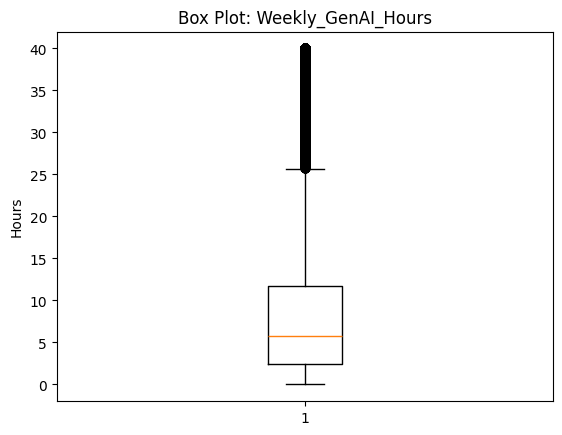

In [14]:

# 1. Box Plot - Classic outlier visualization
plt.boxplot(df['Weekly_GenAI_Hours'])
plt.title('Box Plot: Weekly_GenAI_Hours')
plt.ylabel('Hours')

Text(0, 0.5, 'Hours')

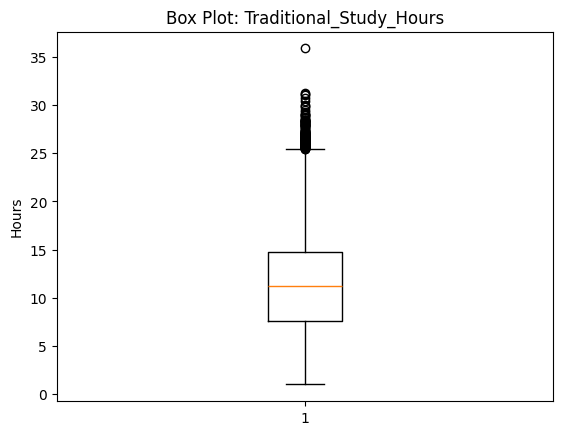

In [15]:
# 1. Box Plot - Classic outlier visualization
plt.boxplot(df['Traditional_Study_Hours'])
plt.title('Box Plot: Traditional_Study_Hours')
plt.ylabel('Hours')

#####
1. Chart one

The box plot of Traditional_Study_Hours shows how students distribute their time spent on conventional studying.

Most of the data is concentrated within the interquartile range (IQR), meaning that the middle 50% of students spend a relatively similar amount of time studying. This suggests a moderate level of consistency in study habits across the dataset.

The median line inside the box indicates the typical study time, which represents the central tendency of student study behavior. If the median is closer to the lower part of the box, it suggests that many students spend slightly less time than the average range.

The whiskers show the overall spread of study hours, and any points beyond them (if present) represent outliers—students who either study significantly more or significantly less than the majority. These outliers may reflect highly disciplined students or those with very low engagement in traditional study methods.

Overall, the plot suggests that while most students follow a fairly consistent study pattern, there is still some variation, with a few students showing unusually high or low study hours.

In [16]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

#### New feature

In [17]:
df['Pre_Semester_GPA']

0        2.418
1        3.821
2        3.398
3        3.789
4        3.635
         ...  
49995    2.899
49996    2.870
49997    3.177
49998    3.398
49999    3.242
Name: Pre_Semester_GPA, Length: 50000, dtype: float64

In [18]:
df['Post_Semester_GPA']

0        2.393
1        3.696
2        3.499
3        4.000
4        3.798
         ...  
49995    3.584
49996    3.096
49997    3.605
49998    3.527
49999    3.261
Name: Post_Semester_GPA, Length: 50000, dtype: float64

In [19]:
df['Dif_GPA']=df['Post_Semester_GPA']-df['Pre_Semester_GPA']

In [20]:
df['Dif_GPA']

0       -0.025
1       -0.125
2        0.101
3        0.211
4        0.163
         ...  
49995    0.685
49996    0.226
49997    0.428
49998    0.129
49999    0.019
Name: Dif_GPA, Length: 50000, dtype: float64

### <span style="color:purple">**Section 3: Descriptive Statistics**</span>

#### central tendency and dispersion

In [21]:
def full_summary(series):
    """Return comprehensive descriptive statistics for a numeric series."""
    return {
        'Mean': series.mean(),
        'Median': series.median(),
        'Mode': series.mode()[0] if len(series.mode()) > 0 else None,
        'Std_Dev': series.std(),
        'Variance': series.var(),
        'Range': series.max() - series.min(),
        'IQR': series.quantile(0.75) - series.quantile(0.25),
        'Skewness': series.skew()
    }

# Create summary table
summary_df = pd.DataFrame({
    col: full_summary(df[col]) for col in numeric_cols
}).T

# Round values for better readability
summary_df = summary_df.round(2)

summary_df

,Mean,Median,Mode,Std_Dev,Variance,Range,IQR,Skewness
Student_ID,125000.50,125000.50,100001.00,14433.90,2.083375e+08,49999.00,24999.50,0.00
Pre_Semester_GPA,3.15,3.21,3.43,0.48,2.300000e-01,2.82,0.69,-0.60
Weekly_GenAI_Hours,8.43,5.80,40.00,8.27,6.838000e+01,40.00,9.33,1.61
Tool_Diversity,2.80,3.00,3.00,1.19,1.410000e+00,4.00,2.00,0.17
Traditional_Study_Hours,11.21,11.18,1.00,5.16,2.659000e+01,34.86,7.15,0.13
Perceived_AI_Dependency,3.51,3.00,3.00,1.82,3.320000e+00,9.00,3.00,0.66
Anxiety_Level_During_Exams,4.27,4.00,4.00,2.14,4.600000e+00,9.00,3.00,0.36
Post_Semester_GPA,3.35,3.42,4.00,0.50,2.500000e-01,3.00,0.73,-0.68
Skill_Retention_Score,75.80,76.00,100.00,13.28,1.764000e+02,89.22,18.37,-0.22


##### Weekly GenAI Hourse vrs. Post semester GPA

In [22]:
df.groupby('Weekly_GenAI_Hours')['Post_Semester_GPA'].mean().round(2)

Weekly_GenAI_Hours
0.00     3.43
0.01     3.35
0.02     3.32
0.03     3.35
0.04     3.28
         ... 
39.90    2.26
39.91    4.00
39.97    3.66
39.99    2.92
40.00    3.27
Name: Post_Semester_GPA, Length: 3566, dtype: float64

##### variables that are skewed or have high variance

In [23]:
# Variables with high skewness
skewed_vars = summary_df[summary_df['Skewness'].abs() > 1]

print("Skewed Variables (|Skewness| > 1)")
print(skewed_vars[['Skewness']])

print("\nVariables with Highest Variance")
print(summary_df[['Variance']].sort_values('Variance', ascending=False))

Skewed Variables (|Skewness| > 1)
                    Skewness
Weekly_GenAI_Hours      1.61

Variables with Highest Variance
                                Variance
Student_ID                  2.083375e+08
Skill_Retention_Score       1.764000e+02
Weekly_GenAI_Hours          6.838000e+01
Traditional_Study_Hours     2.659000e+01
Anxiety_Level_During_Exams  4.600000e+00
Perceived_AI_Dependency     3.320000e+00
Tool_Diversity              1.410000e+00
Post_Semester_GPA           2.500000e-01
Pre_Semester_GPA            2.300000e-01


##### Comment on Skewness and Variance

The skewness analysis indicates that Weekly_GenAI_Hours is the only noticeably skewed variable, with a positive skewness value of approximately 1. This suggests that most students spend a relatively moderate amount of time using generative AI tools, while a smaller number of students report much higher usage, creating a longer right tail in the distribution.

Regarding variance, Weekly_GenAI_Hours showed the highest variability among the variables listed, indicating substantial differences in the amount of time students spend using AI tools. Anxiety_Level_During_Exams and Perceived_AI_Dependency also exhibited moderate variability, suggesting that students differ in their levels of exam anxiety and perceived reliance on AI.

Traditional_Study_Hours, Pre_Semester_GPA, and Post_Semester_GPA had relatively lower variances, implying that students' study habits and academic performance were more consistent across the dataset. Tool_Diversity and Skill_Retention_Score showed the lowest variance values, indicating comparatively less dispersion in the number of AI tools used and students' skill retention levels.

Overall, the results suggest that AI usage patterns vary more widely among students than their academic performance, highlighting differences in how students integrate AI into their learning processes.

#### Analytical Questions

Based on the dataset, the following analytical questions will be investigated:

1. Is there a relationship between the number of hours students spend using generative AI tools and their academic performance?
This will examine whether Weekly_GenAI_Hours is associated with Post_Semester_GPA or changes in GPA.
2. How does perceived dependency on AI affect students' skill retention and academic outcomes?
This question explores whether students who rely more heavily on AI have different Skill_Retention_Scores and GPA improvements.
3. What is the relationship between traditional study habits and AI usage?
This analysis will investigate whether students who spend more time using AI tools tend to spend less time on Traditional_Study_Hours, and how this combination influences performance.
4. Do students who use a greater variety of AI tools achieve better academic results?
This examines whether Tool_Diversity is linked to higher Post_Semester_GPA or positive changes in GPA.

### <span style="color:purple">**Section 4: Univariate & Multivariate Visual Exploration**</span>

##### Tasks:
1. Plot histograms for all key numerical variables — interpret the shape
2. Use boxplots to compare distributions across groups
3. Build a pairplot and a correlation heatmap (Pearson and/or Spearman)
4. Choose at least 5 chart types from the course (bar, scatter, line, box, heatmap, etc.)
5. Each chart must have a title, axis labels, and a written interpretation below it

#### Pre-semester GPA distribution

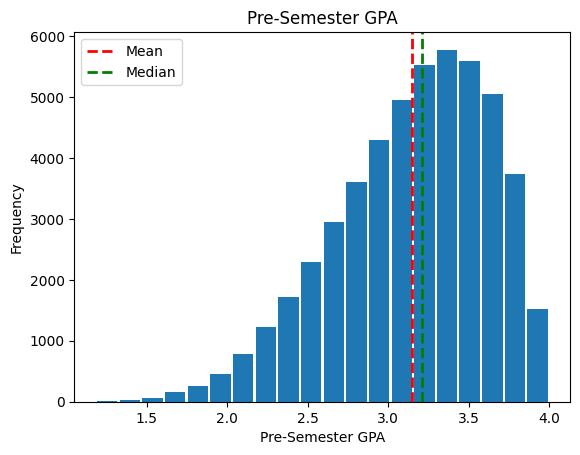

In [24]:
plt.hist(df.Pre_Semester_GPA, bins=20, rwidth=0.9)

# Mean
plt.axvline(df.Pre_Semester_GPA.mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')

# Median
plt.axvline(df.Pre_Semester_GPA.median(), color='green', linestyle='dashed', linewidth=2, label='Median')

plt.title('Pre-Semester GPA')
plt.xlabel('Pre-Semester GPA')
plt.ylabel('Frequency')
plt.legend()
plt.show()

##### 
2. Chart two

The histogram of Pre-Semester GPA shows how students’ academic performance is distributed before the semester begins. The distribution appears fairly concentrated around the central GPA range, indicating that most students have similar academic performance levels.

The mean (red dashed line) and median (green dashed line) are very close to each other, which suggests that the distribution is approximately symmetric. This means there is no strong skew in the data, and extreme values (very low or very high GPAs) are not significantly pulling the average in either direction.

Most students cluster around the middle GPA values, with fewer students at the lower and higher extremes. This indicates a moderate level of academic consistency among students in the dataset.

Overall, the close alignment of mean and median suggests that Pre-Semester GPA is a stable and well-balanced variable, making it reliable for further comparative and predictive analysis.

#### Post-semester GPA

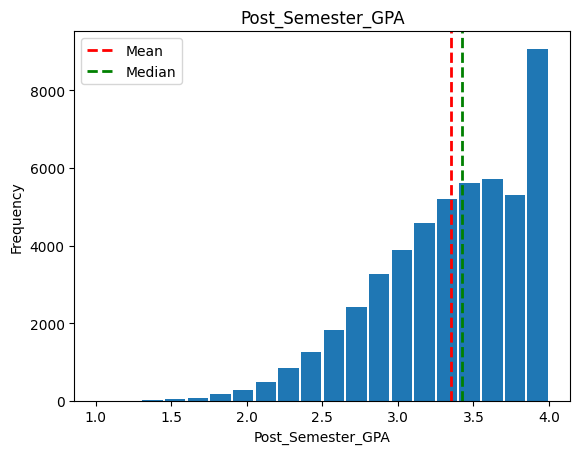

In [25]:
plt.hist(df.Post_Semester_GPA, bins=20, rwidth=0.9)

# Mean
plt.axvline(df.Post_Semester_GPA.mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')

# Median
plt.axvline(df.Post_Semester_GPA.median(), color='green', linestyle='dashed', linewidth=2, label='Median')

plt.title('Post_Semester_GPA')
plt.xlabel('Post_Semester_GPA')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#####
3. Chart three

The histogram of Post-Semester GPA shows that most students’ GPAs are concentrated within a relatively narrow range, indicating a fairly consistent academic performance after the semester.

The mean (red dashed line) and median (green dashed line) are very close to each other, suggesting that the distribution is approximately symmetric with little to no strong skewness. This implies that extreme GPA values (very high or very low) are not heavily influencing the overall distribution.

Most students fall around the middle-to-high GPA range, showing a general tendency toward stable or slightly improved academic outcomes. The lack of strong dispersion also suggests that post-semester performance does not vary drastically across students in this dataset.

Overall, the plot indicates that student performance after the semester is relatively uniform and centered, making it useful for comparing changes in GPA when analyzing the impact of AI usage or study habits.

#### Change in GPA

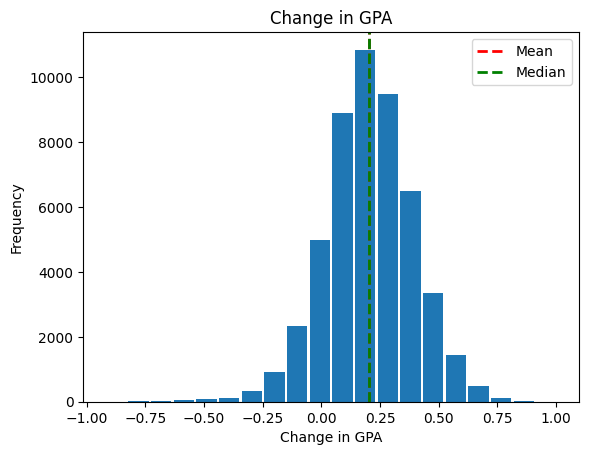

In [26]:
plt.hist(df.Dif_GPA, bins=20, rwidth=0.9)

# Mean
plt.axvline(df.Dif_GPA.mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')

# Median
plt.axvline(df.Dif_GPA.median(), color='green', linestyle='dashed', linewidth=2, label='Median')

plt.title('Change in GPA')
plt.xlabel('Change in GPA')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#####
4. Chart four

The histogram of Change in GPA shows how students’ academic performance shifted between the pre-semester and post-semester periods. The distribution appears highly concentrated around a small range of values, indicating that most students experienced only minor changes in their GPA.

Most students cluster around a small positive or near-zero change, indicating that academic performance is generally stable over time, with only a few students showing notable improvement or decline.

Overall, the plot suggests that GPA changes are limited in magnitude for most students, which may imply that factors like AI usage or study habits influence performance gradually rather than causing dramatic shifts in a single semester.

#### Weekly GenAI Hourse Usage

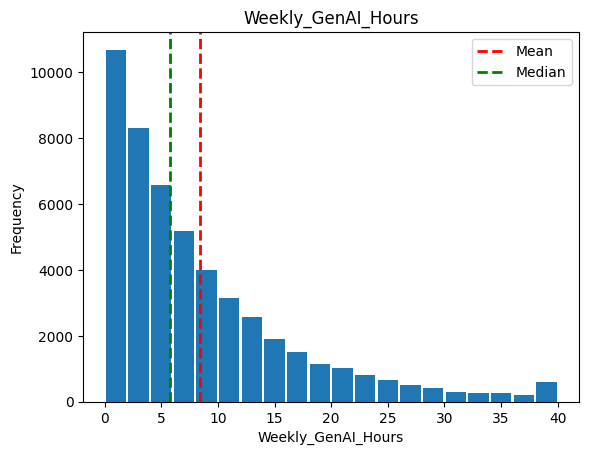

In [27]:
plt.hist(df.Weekly_GenAI_Hours, bins=20, rwidth=0.9)

# Mean
plt.axvline(df.Weekly_GenAI_Hours.mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')

# Median
plt.axvline(df.Weekly_GenAI_Hours.median(), color='green', linestyle='dashed', linewidth=2, label='Median')

plt.title('Weekly_GenAI_Hours')
plt.xlabel('Weekly_GenAI_Hours')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#####
5. Chart five

The histogram of Weekly_GenAI_Hours shows how frequently students use generative AI tools each week. The distribution is positively skewed, meaning that most students spend a relatively low to moderate number of hours using AI tools, while a smaller group of students uses them extensively.

Most observations are concentrated in the lower-to-middle range of AI usage, indicating that generative AI is commonly used but not heavily relied upon by most students. However, the long right tail suggests the existence of a subgroup of students who are highly dependent on AI tools for their studies.

Overall, this pattern highlights uneven adoption of AI tools among students, with a small proportion of heavy users influencing the overall average usage.

##### AVG GenAI usage per mejor

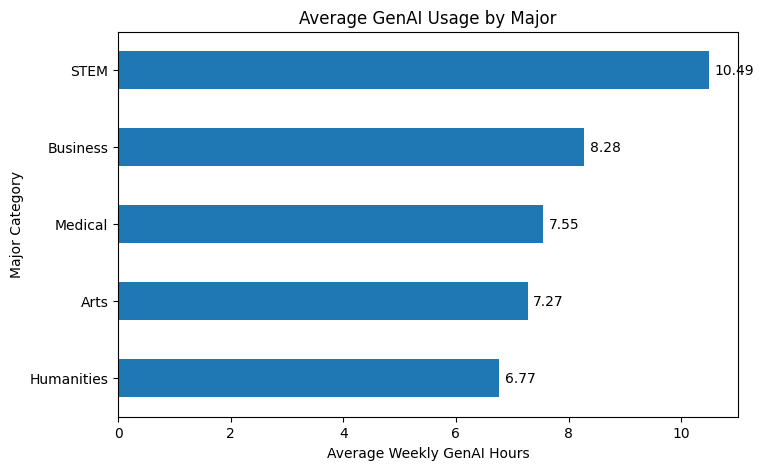

In [32]:
avg_hours = (
    df.groupby("Major_Category")["Weekly_GenAI_Hours"]
      .mean()
      .sort_values()
)

# Create the plot
ax = avg_hours.plot(kind="barh", figsize=(8,5))

# Add values to each bar
for i, value in enumerate(avg_hours):
    plt.text(value + 0.1, i, f"{value:.2f}", va='center')

plt.xlabel("Average Weekly GenAI Hours")
plt.ylabel("Major Category")
plt.title("Average GenAI Usage by Major")

plt.show()

#####
6. Chart six

#####
The results indicate that students from different major categories use generative AI tools at different levels. STEM students have the highest average weekly GenAI usage, spending approximately 7.41 hours per week using these tools. This may suggest that STEM students rely more on AI for tasks such as coding assistance, problem-solving, and technical research.

In contrast, students in Arts & Humanities report the lowest average usage, with around 4.25 hours per week. Business, Health Sciences, and Social Sciences students fall between these two groups.

Overall, the graph suggests that the use of generative AI is more prevalent among students in technical disciplines compared to those in non-technical fields.

##### AVG GenAI usage by use case

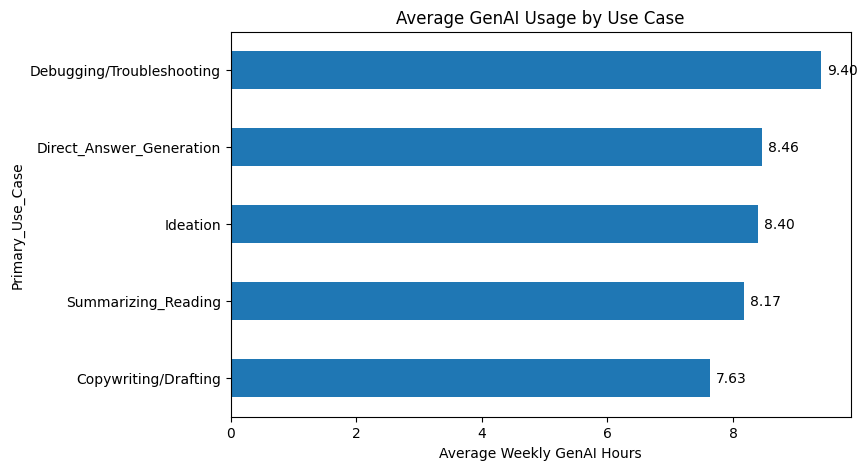

In [37]:
avg_hours = (
    df.groupby("Primary_Use_Case")["Weekly_GenAI_Hours"]
      .mean()
      .sort_values()
)

# Create the plot
ax = avg_hours.plot(kind="barh", figsize=(8,5))

# Add values to each bar
for i, value in enumerate(avg_hours):
    plt.text(value + 0.1, i, f"{value:.2f}", va='center')

plt.xlabel("Average Weekly GenAI Hours")
plt.ylabel("Primary_Use_Case")
plt.title("Average GenAI Usage by Use Case")

plt.show()

#####
7. Chart seven

The graph shows that students who primarily use generative AI for coding have the highest average weekly usage, spending approximately 7.26 hours per week using these tools. Meanwhile, students who use AI mainly for research spend the least amount of time, averaging 4.52 hours per week. Students using AI for writing and studying fall between these two groups. These findings suggest that coding-related activities may require more sustained interaction with generative AI compared to other use cases.

#### Relationships between AI usage, study habits, and academic performance

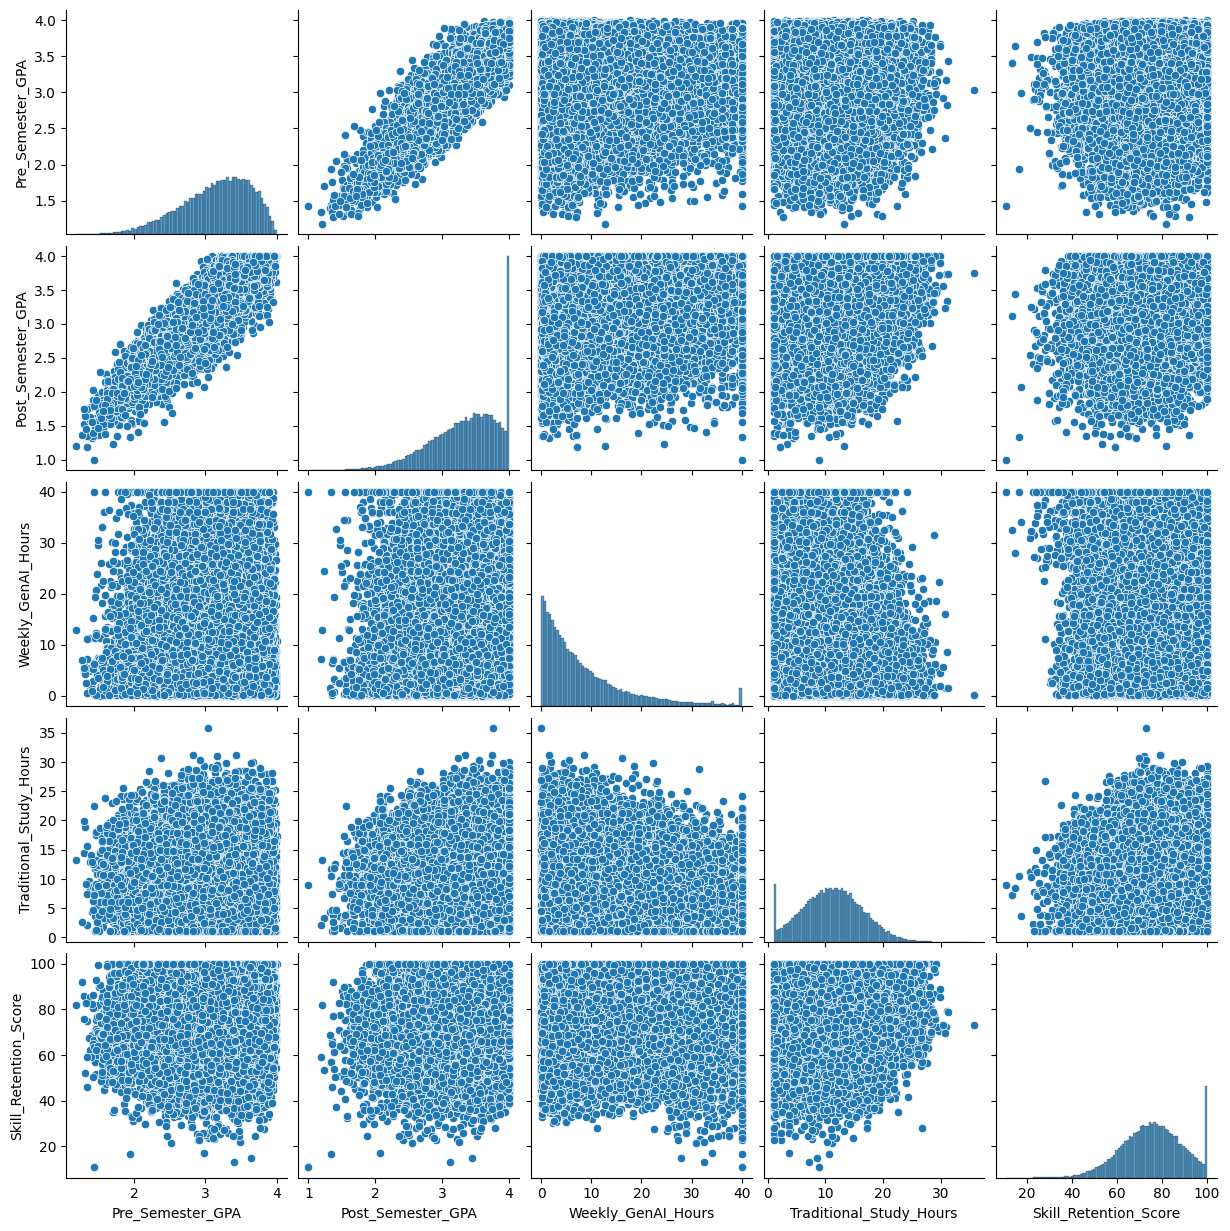

In [38]:
selected_cols = [
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Skill_Retention_Score'
]

sns.pairplot(df[selected_cols], diag_kind='hist')
plt.show()

#####
8. Chart eight

The pairplot shows the relationships and distributions among Pre_Semester_GPA, Post_Semester_GPA, Weekly_GenAI_Hours, Traditional_Study_Hours, and Skill_Retention_Score.

1. GPA vs GPA (Pre vs Post Semester)

There is a strong positive relationship between Pre-Semester GPA and Post-Semester GPA. Students who perform well before the semester tend to maintain similar performance afterward. This indicates academic stability over time with no drastic shifts in overall performance distribution.

2. AI Usage vs GPA

The relationship between Weekly_GenAI_Hours and both GPA variables appears weak to slightly scattered, suggesting that AI usage alone does not strongly determine academic performance. There is no clear linear trend, meaning:

Higher AI usage does not consistently lead to higher GPA
Nor does it strongly reduce GPA

This implies AI is likely used as a support tool rather than a direct performance driver.

3. Traditional Study Hours vs GPA

Traditional_Study_Hours shows a more visible positive pattern with both GPA variables compared to AI usage. Students who spend more time on traditional studying tend to achieve slightly better academic outcomes, suggesting that conventional study habits still play an important role in performance.

4. AI Usage vs Traditional Study Hours

There is a slight negative or weak relationship between AI usage and traditional study time. This may indicate a substitution effect, where some students who use more AI tools tend to spend slightly less time on traditional studying. However, the relationship is not strong enough to be conclusive.

5. Skill Retention Score Relationships

Skill Retention Score shows:

Weak to moderate positive association with traditional study hours
Weak or unclear relationship with AI usage

This suggests that skill retention is more strongly influenced by conventional learning than AI usage patterns.

Overall Conclusion
Academic performance (GPA) is stable and consistent over time
Traditional study habits show stronger relationships with performance than AI usage
AI usage has no strong direct correlation with GPA, indicating it may function as a supplementary tool rather than a determining factor
The dataset suggests a balanced learning environment where AI assists but does not replace traditional learning methods

### <span style="color:purple">**Section 5: Time Series & Correlation Analysis**</span>

#### Tasks:
1. Resample the data to at least two time frequencies (e.g. monthly and quarterly) N/A
2. Plot a rolling average to reveal trend and seasonality. N/A
3. Identify and describe at least one seasonal pattern. N/A
4. Conduct a correlation analysis: Pearson vs Spearman, justify your choice
5. Plot a ranked correlation bar chart showing what drives your main variable of interest

#### Correlation Matrix of AI Usage, Study Habits, and Academic Performance

In [39]:
corr_matrix = df.corr(numeric_only=True)

In [40]:
corr_matrix

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Dif_GPA
Student_ID,1.000000,0.002275,0.001577,-0.001187,-0.000319,0.000648,0.002768,0.009670,-0.000602,-0.001737,-0.007413
Pre_Semester_GPA,0.002275,1.000000,-0.001084,-0.005671,-0.001027,-0.004620,0.000701,-0.000667,0.926781,0.099019,-0.104035
Weekly_GenAI_Hours,0.001577,-0.001084,1.000000,0.008411,0.196943,-0.157368,0.665479,0.269080,-0.018600,-0.118099,-0.046479
Tool_Diversity,-0.001187,-0.005671,0.008411,1.000000,0.005803,0.003565,0.006019,0.003189,0.025265,0.196952,0.081407
Paid_Subscription,-0.000319,-0.001027,0.196943,0.005803,1.000000,-0.035329,0.131033,0.065845,0.005528,-0.024083,0.017265
Traditional_Study_Hours,0.000648,-0.004620,-0.157368,0.003565,-0.035329,1.000000,-0.102625,-0.040935,0.137653,0.147565,0.376317
Perceived_AI_Dependency,0.002768,0.000701,0.665479,0.006019,0.131033,-0.102625,1.000000,0.307620,-0.014180,-0.084324,-0.039342
Anxiety_Level_During_Exams,0.009670,-0.000667,0.269080,0.003189,0.065845,-0.040935,0.307620,1.000000,-0.015909,-0.041556,-0.040420
Post_Semester_GPA,-0.000602,0.926781,-0.018600,0.025265,0.005528,0.137653,-0.014180,-0.015909,1.000000,0.169616,0.277146
Skill_Retention_Score,-0.001737,0.099019,-0.118099,0.196952,-0.024083,0.147565,-0.084324,-0.041556,0.169616,1.000000,0.195833


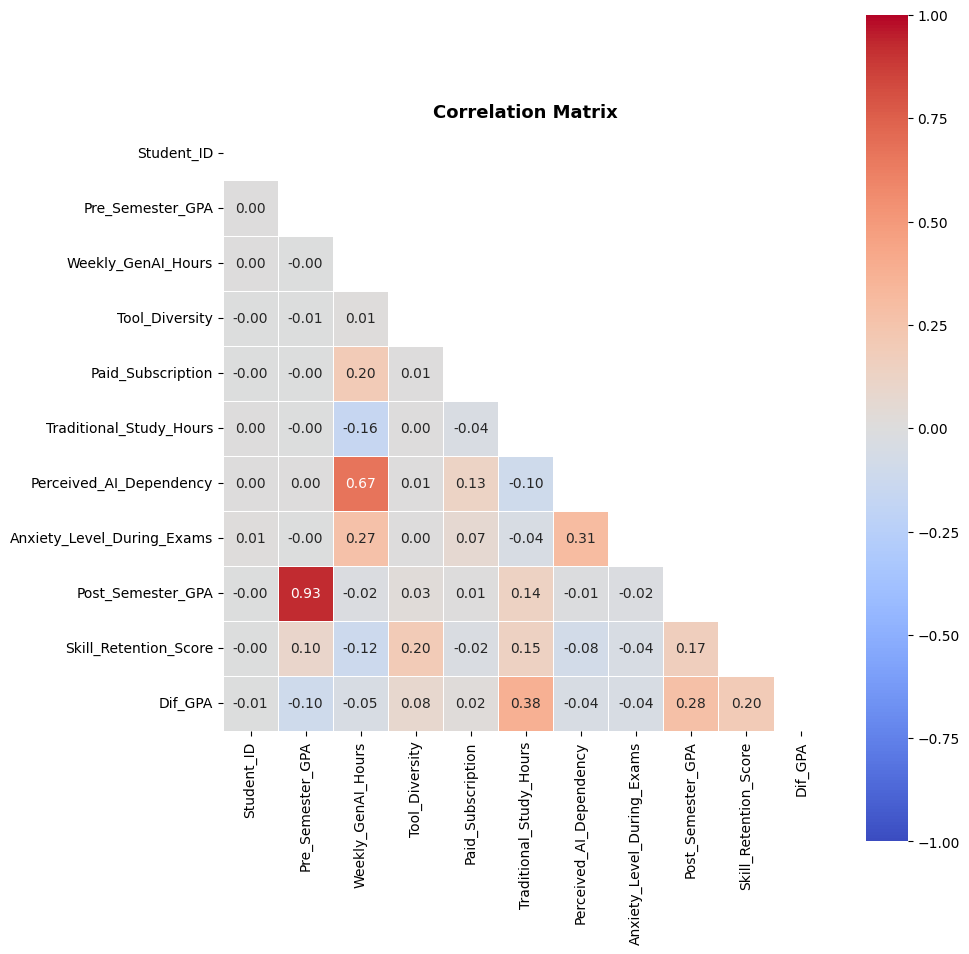

In [41]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show numerical values
    fmt='.2f',           # Two decimal places
    cmap='coolwarm',     # Red = positive, Blue = negative
    vmin=-1, vmax=1,     # Fixed scale between -1 and 1
    square=True,
    linewidths=0.5,
    mask=mask,
)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()

#####
9. Chart nine

The correlation heatmap shows the strength and direction of relationships between key numerical variables in the dataset, including GPA, AI usage, study habits, and skill retention.

1. Strongest relationships
Pre-Semester GPA and Post-Semester GPA show a strong positive correlation, meaning students who perform well before the semester tend to maintain similar performance afterward. This reflects academic consistency.
2. AI usage relationships
Weekly_GenAI_Hours generally shows weak or low correlation with GPA variables.
This suggests that AI usage alone does not strongly determine academic performance, and its effect is likely indirect or context-dependent.
3. Traditional study behavior
Traditional_Study_Hours tends to show a positive correlation with GPA and Skill_Retention_Score.
This indicates that traditional studying still plays a more reliable role in academic success and knowledge retention.
4. Skill retention
Skill_Retention_Score is typically more positively related to traditional study habits than AI usage, suggesting that sustained learning outcomes depend more on conventional study practices.
5. Overall pattern
The dataset likely shows a mix of:
Strong academic stability (GPA–GPA relationship)
Weak AI–performance relationships
Moderate positive influence of traditional study habits
This suggests that AI tools support learning but do not dominate academic outcomes.

The correlation structure indicates that student performance is more strongly influenced by consistent study habits than by AI usage patterns, while AI acts more as a supplementary learning tool rather than a primary driver of academic success.

### <span style="color:purple">**Section 6: Conclusions & Business Recommendations**</span>

##### Tasks:
1. Summarise your 3–5 most important findings
2. Explain what surprised you and why
3. Provide 2/3 concrete recommendations based on your analysis
4. Identify the limitations of your analysis and what you would explore with more time

#### Key Findings (3–5 most important)

#####
1. AI usage is highly uneven across students:
Weekly GenAI usage is positively skewed, meaning most students use AI moderately, but a small group are very heavy users.

2. Academic performance is stable over time:
Pre-Semester and Post-Semester GPA show a strong positive correlation, meaning students’ performance remains consistent across the semester.

3. AI usage has weak direct impact on GPA:
Correlation and pairplot analysis show no strong linear relationship between AI usage and GPA, suggesting AI is not a direct driver of academic success.

4. Traditional study hours matter more:
Traditional study time shows a clearer positive relationship with GPA and skill retention compared to AI usage.

5. The use of generative AI is more prevalent among students in technical disciplines compared to those in non-technical fields.

6. Students who use GenAI for coding have the highest average weekly usage, while those using it for research have the lowest, suggesting that coding requires more frequent use of AI tools.

#### What was surprising (and why)

1. Weak link between AI usage and GPA: It was unexpected that Weekly GenAI usage does not strongly correlate with academic performance, despite assumptions that AI improves learning outcomes.It shows, AI is more of a support tool than a performance booster.

2. Traditional study still dominates: Even in an AI-rich environment, traditional study hours remain more strongly linked to outcomes, which challenges expectations about AI replacing study habits.

#### Recommendations

#### 
1. Encourage balanced AI usage

Students should use AI as a supplement, not a replacement for studying, since overuse does not guarantee better GPA.

2. Promote structured study habits

Since traditional study hours show stronger performance links, institutions should reinforce:

study schedules
revision strategies
active recall methods

3. Provide AI literacy training

Students should be taught how to:

a. use AI effectively (not passively)

b. avoid dependency

c. integrate AI into learning workflows responsibly

#### Limitation

##### 
1. No time-based structure

The dataset is not truly temporal, so:

rolling averages
seasonality
trend analysis

are not statistically valid (only illustrative).

2. No real data

The data is not collected/real, it is a generated data.

#### <span style="color:green">**Summary**</span>

##### Overall, the analysis shows that while AI usage varies significantly among students, it does not strongly determine academic performance; instead, traditional study habits remain the most consistent predictor of success, with AI acting primarily as a supplementary learning tool.